# Diabetes 30-Day Readmission Machine Learning Analysis

**Case Studies in Data Science – Individual Task 1**

This notebook analyses the UCI Diabetes 130-US Hospitals dataset using:

- Decision Tree
- k-Nearest Neighbours (kNN)

The objective is to predict whether a hospital encounter results in readmission within 30 days.

Dataset source:
https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008

In [2]:
# Stage 1 — Load Diabetes dataset

import pandas as pd
import numpy as np

diabetes = pd.read_csv('diabetic_data.csv')

print("Dataset shape:", diabetes.shape)
display(diabetes.head())

Dataset shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


## 1. Dataset Inspection

In [4]:
# Stage 2 — Inspect dataset

print("Column names:")
print(diabetes.columns.tolist())

print("\nData types:")
print(diabetes.dtypes)

print("\nDataset info:")
diabetes.info()

Column names:
['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']

Data types:
encounter_id                 int64
patient_nbr                  int64
race                        object
gender                      object
age            

## 2. Missing Values

In [6]:
# Stage 3 — Convert '?' to missing values

diabetes = diabetes.replace('?', np.nan)

missing = diabetes.isnull().sum()

missing_table = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': (missing / len(diabetes) * 100).round(2)
})

print(missing_table[missing_table['Missing Count'] > 0]
      .sort_values('Missing %', ascending=False))

                   Missing Count  Missing %
weight                     98569      96.86
max_glu_serum              96420      94.75
A1Cresult                  84748      83.28
medical_specialty          49949      49.08
payer_code                 40256      39.56
race                        2273       2.23
diag_3                      1423       1.40
diag_2                       358       0.35
diag_1                        21       0.02


In [7]:
# Stage 4 — Check duplicate records

print("Exact duplicate rows:")
print(diabetes.duplicated().sum())

print("\nUnique patients:")
print(diabetes['patient_nbr'].nunique())

print("\nTotal hospital encounters:")
print(len(diabetes))

Exact duplicate rows:
0

Unique patients:
71518

Total hospital encounters:
101766


In [8]:
# Stage 5 — Examine readmission target

print("Readmission counts:")
print(diabetes['readmitted'].value_counts())

print("\nReadmission percentages:")
print(
    (diabetes['readmitted'].value_counts(normalize=True) * 100)
    .round(2)
)

Readmission counts:
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

Readmission percentages:
readmitted
NO     53.91
>30    34.93
<30    11.16
Name: proportion, dtype: float64


## 3. Binary Target Preparation

The original readmission outcome has three classes:

- `NO`
- `>30`
- `<30`

For this analysis:

- `1` = readmitted within 30 days
- `0` = not readmitted within 30 days

In [10]:
# Stage 6 — Create binary target

diabetes['readmitted_30'] = (
    diabetes['readmitted'] == '<30'
).astype(int)

print("Binary target counts:")
print(diabetes['readmitted_30'].value_counts())

print("\nBinary target percentages:")
print(
    (diabetes['readmitted_30'].value_counts(normalize=True) * 100)
    .round(2)
)

Binary target counts:
readmitted_30
0    90409
1    11357
Name: count, dtype: int64

Binary target percentages:
readmitted_30
0    88.84
1    11.16
Name: proportion, dtype: float64


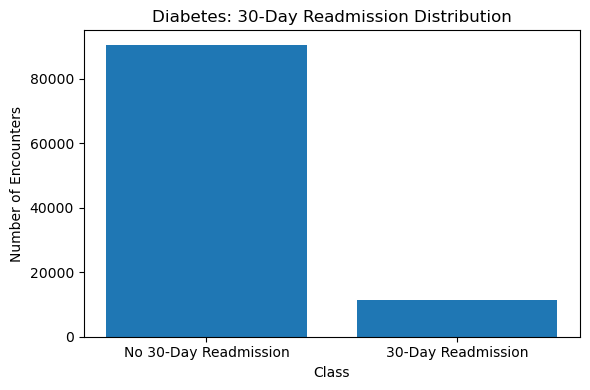

In [11]:
# Diabetes target distribution

import matplotlib.pyplot as plt

counts = diabetes['readmitted_30'].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(['No 30-Day Readmission', '30-Day Readmission'], counts.values)

plt.title('Diabetes: 30-Day Readmission Distribution')
plt.ylabel('Number of Encounters')
plt.xlabel('Class')

plt.tight_layout()
plt.show()

In [12]:
# Stage 7 — Prepare features and target

drop_columns = [
    'encounter_id',
    'patient_nbr',
    'readmitted',
    'readmitted_30',
    'weight',
    'payer_code',
    'medical_specialty',
    'max_glu_serum',
    'A1Cresult'
]

X_diabetes = diabetes.drop(columns=drop_columns)
y_diabetes = diabetes['readmitted_30']

print("Feature matrix shape:", X_diabetes.shape)
print("Target shape:", y_diabetes.shape)

print("\nRemaining features:")
print(X_diabetes.columns.tolist())

Feature matrix shape: (101766, 42)
Target shape: (101766,)

Remaining features:
['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed']


In [13]:
# Stage 8 — Train/test split

from sklearn.model_selection import train_test_split

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_diabetes,
    y_diabetes,
    test_size=0.20,
    random_state=42,
    stratify=y_diabetes
)

print("Training shape:", X_train_d.shape)
print("Testing shape:", X_test_d.shape)

print("\nTraining target distribution:")
print((y_train_d.value_counts(normalize=True) * 100).round(2))

print("\nTesting target distribution:")
print((y_test_d.value_counts(normalize=True) * 100).round(2))

Training shape: (81412, 42)
Testing shape: (20354, 42)

Training target distribution:
readmitted_30
0    88.84
1    11.16
Name: proportion, dtype: float64

Testing target distribution:
readmitted_30
0    88.84
1    11.16
Name: proportion, dtype: float64


In [14]:
# Stage 9 — Leakage-proof preprocessing

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Numerical features
numeric_features_d = [
    'time_in_hospital',
    'num_lab_procedures',
    'num_procedures',
    'num_medications',
    'number_outpatient',
    'number_emergency',
    'number_inpatient',
    'number_diagnoses'
]

# Everything else is categorical
categorical_features_d = [
    col for col in X_train_d.columns
    if col not in numeric_features_d
]

# Numeric preprocessing
numeric_transformer_d = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical preprocessing
categorical_transformer_d = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine preprocessing
preprocessor_d = ColumnTransformer([
    ('num', numeric_transformer_d, numeric_features_d),
    ('cat', categorical_transformer_d, categorical_features_d)
])

print("Numerical features:", len(numeric_features_d))
print("Categorical features:", len(categorical_features_d))

Numerical features: 8
Categorical features: 34


In [15]:
# Stage 10 — Diabetes Model 1: Decision Tree

from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# Create Decision Tree pipeline
dt_diabetes = Pipeline([
    ('preprocessor', clone(preprocessor_d)),
    ('classifier', DecisionTreeClassifier(
        max_depth=5,
        class_weight='balanced',
        random_state=42
    ))
])

# Train model
dt_diabetes.fit(X_train_d, y_train_d)

# Predictions
y_pred_dt_d = dt_diabetes.predict(X_test_d)
y_prob_dt_d = dt_diabetes.predict_proba(X_test_d)[:, 1]

# Evaluation
print("Diabetes Decision Tree Results")

print("Accuracy :", round(accuracy_score(y_test_d, y_pred_dt_d), 3))
print("Precision:", round(precision_score(y_test_d, y_pred_dt_d), 3))
print("Recall   :", round(recall_score(y_test_d, y_pred_dt_d), 3))
print("F1-score :", round(f1_score(y_test_d, y_pred_dt_d), 3))
print("ROC-AUC  :", round(roc_auc_score(y_test_d, y_prob_dt_d), 3))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_d, y_pred_dt_d))

Diabetes Decision Tree Results
Accuracy : 0.68
Precision: 0.18
Recall   : 0.527
F1-score : 0.269
ROC-AUC  : 0.659

Confusion Matrix:
[[12651  5432]
 [ 1075  1196]]


In [16]:
# Stage 11 — Diabetes kNN

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier

# Take a stratified sample of 20,000 training records
X_knn_train, _, y_knn_train, _ = train_test_split(
    X_train_d,
    y_train_d,
    train_size=20000,
    random_state=42,
    stratify=y_train_d
)

print("kNN training sample:", X_knn_train.shape)

# Build kNN pipeline
knn_diabetes = Pipeline([
    ('preprocessor', clone(preprocessor_d)),
    ('classifier', KNeighborsClassifier(
        n_neighbors=5,
        n_jobs=-1
    ))
])

# Train on the smaller representative sample
knn_diabetes.fit(X_knn_train, y_knn_train)

# Evaluate on the ORIGINAL test set
y_pred_knn_d = knn_diabetes.predict(X_test_d)
y_prob_knn_d = knn_diabetes.predict_proba(X_test_d)[:, 1]

print("\nDiabetes kNN Results")
print("Accuracy :", round(accuracy_score(y_test_d, y_pred_knn_d), 3))
print("Precision:", round(precision_score(y_test_d, y_pred_knn_d), 3))
print("Recall   :", round(recall_score(y_test_d, y_pred_knn_d), 3))
print("F1-score :", round(f1_score(y_test_d, y_pred_knn_d), 3))
print("ROC-AUC  :", round(roc_auc_score(y_test_d, y_prob_knn_d), 3))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_d, y_pred_knn_d))

kNN training sample: (20000, 42)

Diabetes kNN Results
Accuracy : 0.88
Precision: 0.264
Recall   : 0.041
F1-score : 0.07
ROC-AUC  : 0.558

Confusion Matrix:
[[17827   256]
 [ 2179    92]]


In [17]:
# Stage 12 — Compare Diabetes models

import pandas as pd

results_diabetes = pd.DataFrame({
    'Model': ['Decision Tree', 'kNN'],
    'Accuracy': [
        accuracy_score(y_test_d, y_pred_dt_d),
        accuracy_score(y_test_d, y_pred_knn_d)
    ],
    'Precision': [
        precision_score(y_test_d, y_pred_dt_d),
        precision_score(y_test_d, y_pred_knn_d)
    ],
    'Recall': [
        recall_score(y_test_d, y_pred_dt_d),
        recall_score(y_test_d, y_pred_knn_d)
    ],
    'F1-score': [
        f1_score(y_test_d, y_pred_dt_d),
        f1_score(y_test_d, y_pred_knn_d)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test_d, y_prob_dt_d),
        roc_auc_score(y_test_d, y_prob_knn_d)
    ]
})

print(results_diabetes.round(3))

           Model  Accuracy  Precision  Recall  F1-score  ROC-AUC
0  Decision Tree      0.68      0.180   0.527     0.269    0.659
1            kNN      0.88      0.264   0.041     0.070    0.558


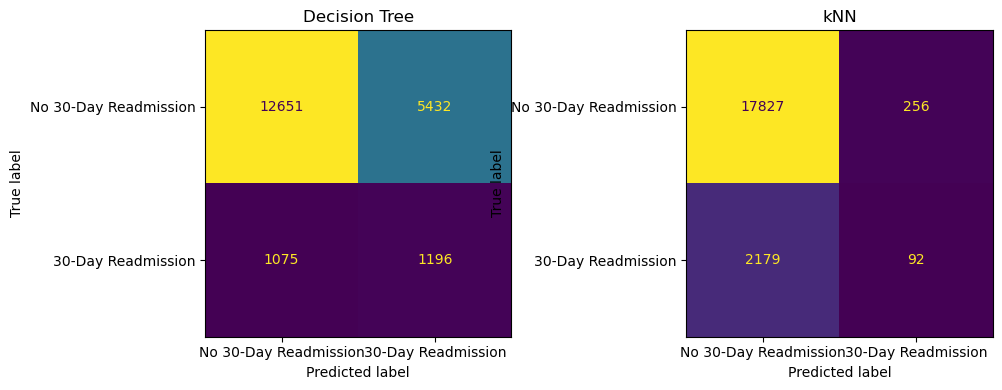

In [18]:
# Stage 13 — Diabetes Confusion Matrices

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test_d, y_pred_dt_d,
    display_labels=['No 30-Day Readmission', '30-Day Readmission'],
    ax=axes[0],
    colorbar=False
)
axes[0].set_title('Decision Tree')

ConfusionMatrixDisplay.from_predictions(
    y_test_d, y_pred_knn_d,
    display_labels=['No 30-Day Readmission', '30-Day Readmission'],
    ax=axes[1],
    colorbar=False
)
axes[1].set_title('kNN')

plt.tight_layout()
plt.show()

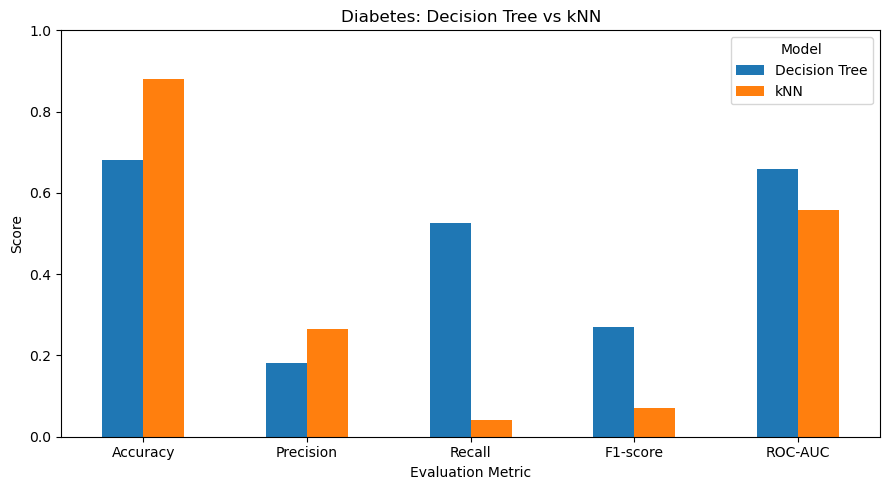

In [19]:
# Stage 14 — Diabetes Model Performance Comparison

import matplotlib.pyplot as plt

results_plot_d = results_diabetes.set_index('Model').T

results_plot_d.plot(kind='bar', figsize=(9, 5))

plt.title('Diabetes: Decision Tree vs kNN')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xlabel('Evaluation Metric')
plt.xticks(rotation=0)
plt.legend(title='Model')

plt.tight_layout()

# Save graph for Overleaf
plt.savefig(
    'diabetes_model_comparison.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [20]:
# Rebuild Decision Tree with independent preprocessing

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier

dt_diabetes = Pipeline([
    ('preprocessor', clone(preprocessor_d)),
    ('classifier', DecisionTreeClassifier(
        max_depth=5,
        class_weight='balanced',
        random_state=42
    ))
])

dt_diabetes.fit(X_train_d, y_train_d)

# Recalculate predictions
y_pred_dt_d = dt_diabetes.predict(X_test_d)
y_prob_dt_d = dt_diabetes.predict_proba(X_test_d)[:, 1]

print("Decision Tree rebuilt successfully.")

Decision Tree rebuilt successfully.


In [21]:
# Stage 15 — Diabetes Decision Tree Feature Importance

import pandas as pd

# Get transformed feature names
feature_names_d = (
    dt_diabetes
    .named_steps['preprocessor']
    .get_feature_names_out()
)

# Get Decision Tree feature importance
importance_d = (
    dt_diabetes
    .named_steps['classifier']
    .feature_importances_
)

# Create importance table
feature_importance_d = pd.DataFrame({
    'Feature': feature_names_d,
    'Importance': importance_d
}).sort_values(
    'Importance',
    ascending=False
)

print(feature_importance_d.head(10).round(3))

                               Feature  Importance
6                num__number_inpatient       0.569
34     cat__discharge_disposition_id_1       0.155
44    cat__discharge_disposition_id_11       0.142
54    cat__discharge_disposition_id_22       0.060
7                num__number_diagnoses       0.030
0                num__time_in_hospital       0.014
1563                   cat__diag_3_250       0.010
1721                   cat__diag_3_401       0.008
602                    cat__diag_1_786       0.006
27            cat__admission_type_id_2       0.003


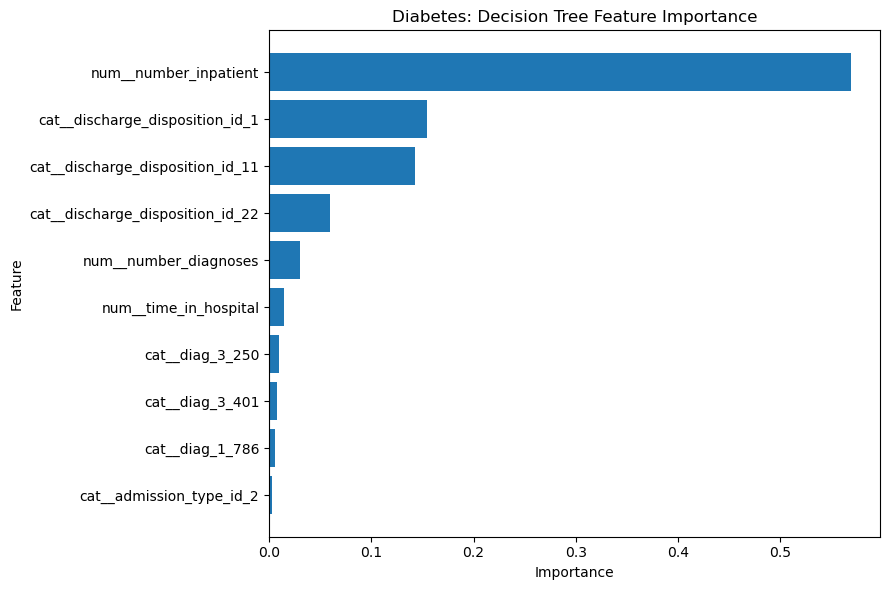

In [22]:
# Stage 15B — Diabetes Feature Importance Graph

top_features_d = (
    feature_importance_d
    .head(10)
    .sort_values('Importance', ascending=True)
)

plt.figure(figsize=(9, 6))
plt.barh(top_features_d['Feature'], top_features_d['Importance'])

plt.title('Diabetes: Decision Tree Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()